# Consecutive Dry Days

Analysis of dry-day frequency and consecutive dry spells at the selected GHCN station. Dry conditions are a key drought and water-stress indicator for Pacific Island sites.



```{glue:figure} number_dry_days
:scale: 60%
:align: center
```

```{glue:figure} maximum_cons_dry_days
:scale: 60%
:align: center
```

**Figure. Annual dry days (top) and maximum number of consecutive days (bottom) over the period 1951–2024 at Koror.**  Dry days are defined as days below 1mm (0.04 inches) threshold.  Consecutive dry days is a measure of the longest sequence of days in a year where rainfall is less than 1 mm (0.04 inches). The dashed black line represents a trend that is not statistically significant.  

## Setup

Import libraries and helper functions from `functions/rainfall.py` and [indicators_setup](https://github.com/lauracagigal/indicators_setup).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import os.path as op
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from myst_nb import glue

sys.path.append("../../../../indicators_setup")
from ind_setup.plotting import plot_bar_probs
from ind_setup.colors import get_df_col
from ind_setup.core import fontsize

sys.path.append("../../functions")
from rainfall import (
    load_site_config,
    site_config_filename,
    build_site_figures_dir,
    consecutive_dry_days,
    count_consecutive_days,
    build_output_filename,
    persist_dry_days_outputs,
)


### Define location and variables of interest

Set `site_key` to match the site name used in `00_site_setup.ipynb`. Site metadata and output paths are loaded from `data/sites/<site_key>.json`.


### Get Data

Load the cached daily `PRCP` pickle from `data/rainfall/GHCN_<station_id>.pkl`.


In [2]:
site_key = "Palau"

site_config_path = Path("../../data/sites") / site_config_filename(site_key)
site_cfg = load_site_config(site_config_path)

site_name = site_cfg.get("site_name", "Site")
site_lon = float(site_cfg["site_lon"])
site_lat = float(site_cfg["site_lat"])
country = site_cfg["country"]
ghcn_station_id = site_cfg["ghcn_station_id"]
ghcn_station_name = site_cfg.get("ghcn_station_name", "")
vars_interest = list(site_cfg.get("vars_interest", ["PRCP"]))
ref_start = str(site_cfg.get("reference_period_start", "1961"))
ref_end = str(site_cfg.get("reference_period_end", "1990"))



In [3]:
data_base_dir = Path("../../data")
site_figures_dir = build_site_figures_dir(Path("../../outputs"), site_name, site_lon, site_lat)
data_dir = Path(data_base_dir, "rainfall")

data_dir.mkdir(parents=True, exist_ok=True)
path_data = str(data_dir)


### Observations from Station


[GHCN-Daily documentation](https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/doc/GHCND_documentation.pdf)


The data used for this analysis comes from the [GHCN-Daily](https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/) database (NOAA NCEI).

GHCN-Daily provides historical daily precipitation records over global land areas. Records from numerous sources are merged and subjected to quality-assurance reviews. The variable used here is **`PRCP`** (daily precipitation total, mm).

**Data loading:** this notebook reads the pre-processed pickle created by `00_site_setup.ipynb`. It does **not** re-download from NOAA.

**Outputs:** figures → `outputs/figures/<site_tag>/`; tables and JSON → `outputs/tables/<site_tag>/`.


In [4]:
pickle_path = data_dir / f"GHCN_{ghcn_station_id}.pkl"
data = pd.read_pickle(pickle_path)
print(f"Loaded {len(data)} daily records from {pickle_path}")
data_daily = data.copy()


Loaded 26652 daily records from ../../data/rainfall/GHCN_PSW00040309.pkl


In [5]:
data['wet_day'] = np.where(data['PRCP'] > 1, 1, np.where((np.isnan(data['PRCP'])==True), np.nan, 0))



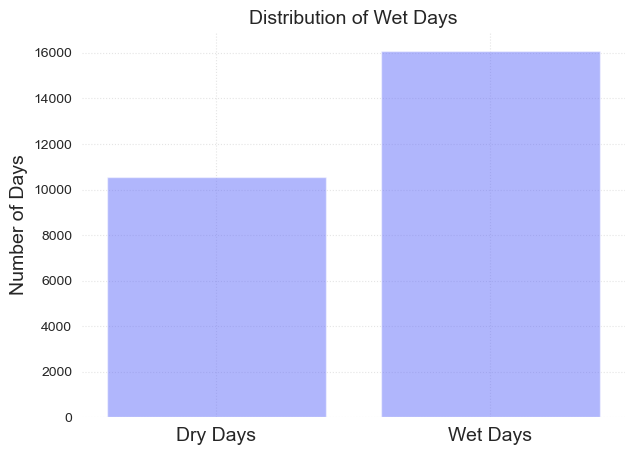

In [6]:
fig, ax = plot_bar_probs(x = [0, 1], y = data.groupby('wet_day').count()['PRCP'].values, labels = ['Dry Days', 'Wet Days'])
ax.set_title('Distribution of Wet Days', fontsize = fontsize)
ax.set_ylabel('Number of Days', fontsize = fontsize)
plt.savefig(
    site_figures_dir / build_output_filename('F6a_Wet_dry_distribution', site_name, site_lon, site_lat),
    dpi=300, bbox_inches='tight',
)


In [7]:
np.array(data.groupby('wet_day').count()['PRCP'].values/len(np.unique(data.index.year)))[0]



np.float64(140.69333333333333)

## Analysis

**Definitions used in this notebook:**

| Term | Criterion |
|---|---|
| Dry day | `PRCP < 1 mm` (0.04 inches) |
| Wet day | `PRCP > 1 mm` |
| Consecutive dry days | Longest run of dry days within a calendar year |
| Year filter | Years with ≥ 300 daily observations are retained |


#### Wet / dry day classification


Each day is classified as wet or dry using the 1 mm threshold (WMO / ETCCDI convention). The stacked bar chart shows the overall distribution of wet and dry days across the full record.


In [8]:
threshold = 1 #np.percentile(data['PRCP'].dropna(), 90)
data['wet_day_t'] = np.where(data['PRCP'] > threshold, 1, np.where((np.isnan(data['PRCP'])==True), np.nan, 0))



In [9]:
data_th = data.groupby([data.index.year, data.wet_day_t]).count()['PRCP']
data_th = data_th/data.groupby(data.index.year).count()['PRCP'] * 365



### Annual dry-day counts


Text(0, 0.5, 'Number of days')

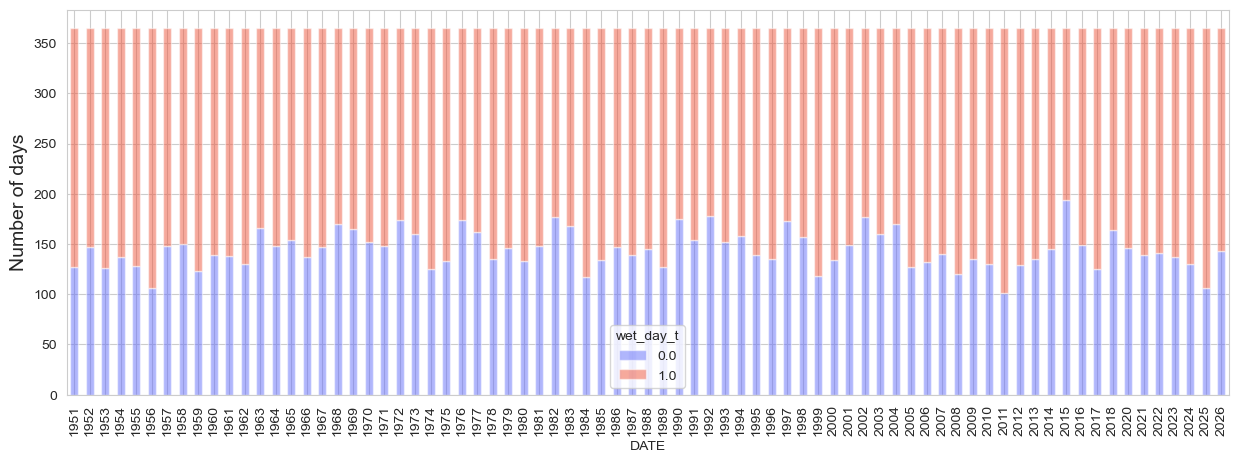

In [10]:
fig, ax = plt.subplots(figsize = [15, 5])
data_th.unstack().plot(kind = 'bar', stacked = True, ax = ax, color = get_df_col()[:2], edgecolor = 'white', alpha = .5)
ax.set_ylabel('Number of days', fontsize = fontsize)



#### Number of dry days per year

Annual count of days with precipitation below 1 mm, with a fitted linear trend. Saved as `F6a_Number_dry_<site_tag>.png`.


KeyError: "['index'] not in index"

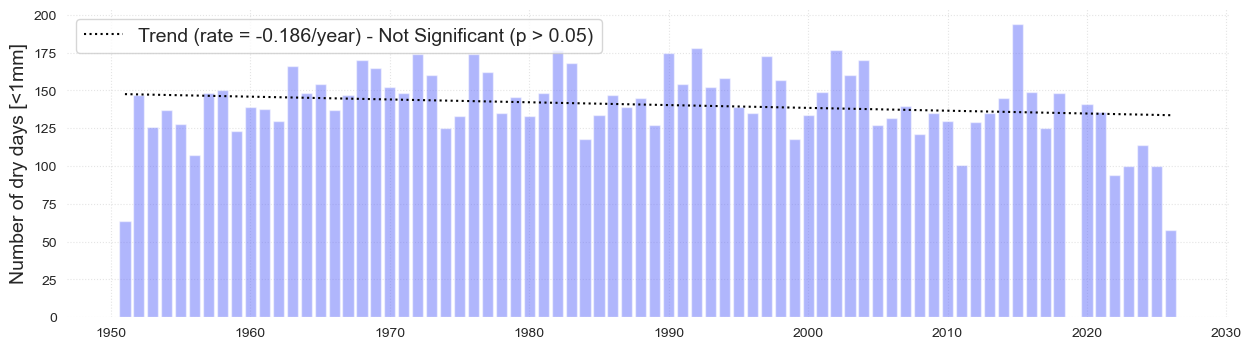

In [11]:
#Dry days
data2 = data.loc[data['wet_day_t'] == 0]
data2 = data2.groupby(data2.index.year).count()
fig, ax, trend_dry_days = plot_bar_probs(x = data2.index, y = data2.PRCP.values, trendline = True,
               y_label = 'Number of dry days [<1mm]', figsize = [15, 4], return_trend = True)
dry_days_per_year = data2.reset_index()[['index', 'PRCP']].rename(columns={'index': 'year', 'PRCP': 'dry_days'})
plt.savefig(
    site_figures_dir / build_output_filename('F6a_Number_dry', site_name, site_lon, site_lat),
    dpi=300, bbox_inches='tight',
)
glue("number_dry_days", fig, display=False)
glue('trend_dry', float(trend_dry_days), display=False)


In [ ]:
data = data.groupby(data.index.year).filter(lambda x: len(x) >= 300).dropna()
data['dry_day'] = np.where(data['PRCP'] < threshold, 1, 0)



In [ ]:
consecutive_dry_year = data.groupby(data.index.year)['dry_day'].apply(consecutive_dry_days)
data['below_threshold'] = data['PRCP'] < threshold
data['consecutive_days'] = count_consecutive_days(data['below_threshold'])



#### Consecutive dry days


**Mean consecutive dry days** — average length of the longest dry spell within each year. Uses `count_consecutive_days()` from `functions/rainfall.py`. Saved as `F6b_Mean_consecutive_dry_<site_tag>.png`.


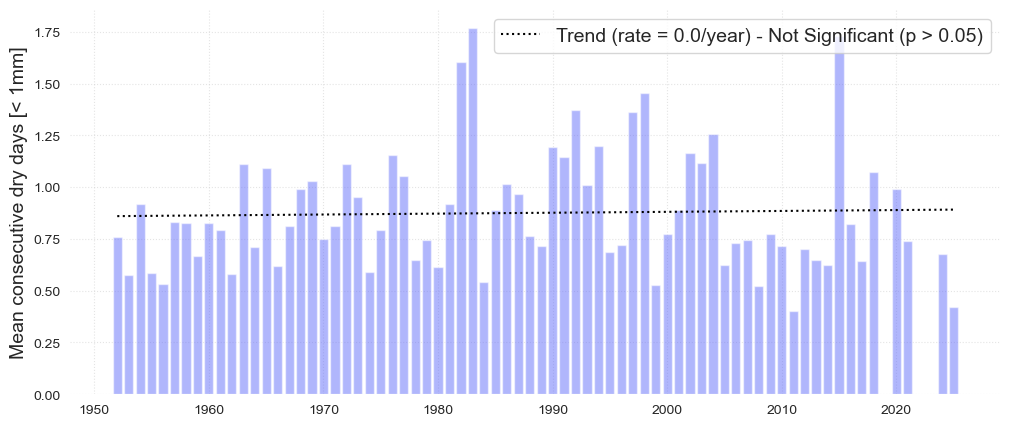

In [ ]:
fig, ax = plot_bar_probs(np.unique(data.index.year), data.groupby(data.index.year)['consecutive_days'].mean(),
               trendline =True, y_label = 'Mean consecutive dry days [< 1mm]',
               figsize = [12, 5])
consecutive_mean_per_year = data.groupby(data.index.year)['consecutive_days'].mean()
plt.savefig(
    site_figures_dir / build_output_filename('F6b_Mean_consecutive_dry', site_name, site_lon, site_lat),
    dpi=300, bbox_inches='tight',
)
glue("mean_dry_days_fig", fig, display=False)


**Maximum consecutive dry days** — longest uninterrupted dry spell in each year. Uses `consecutive_dry_days()` from `functions/rainfall.py`. Saved as `F6b_Consecutive_dry_<site_tag>.png`.


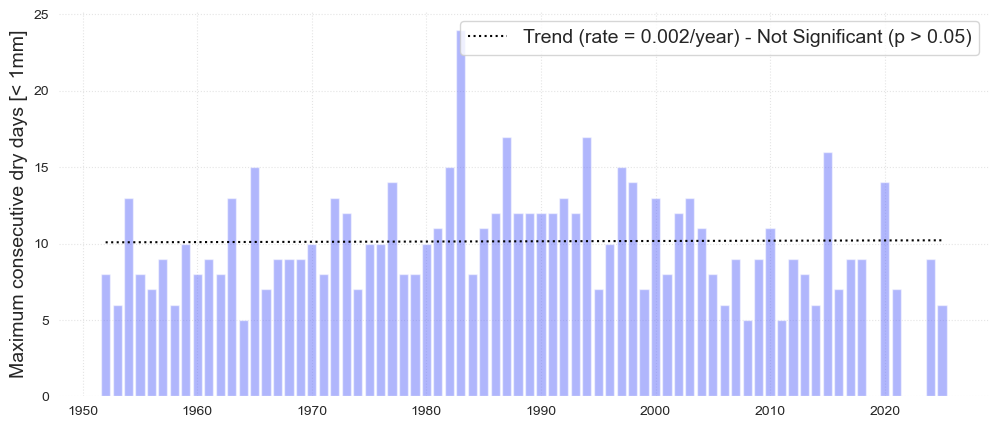

In [ ]:
fig, ax, trend_max_ndays = plot_bar_probs(np.unique(data.index.year), data.groupby(data.index.year)['consecutive_days'].max(),
               trendline =True, y_label = 'Maximum consecutive dry days [< 1mm]', return_trend = True,
               figsize = [12, 5])
consecutive_max_per_year = data.groupby(data.index.year)['consecutive_days'].max()

glue("maximum_cons_dry_days", fig, display=False)

plt.savefig(
    site_figures_dir / build_output_filename('F6b_Consecutive_dry', site_name, site_lon, site_lat),
    dpi=300, bbox_inches='tight',
)


### Summary table and persisted outputs

Calls `persist_dry_days_outputs()` to save:

- `R_dry_days_per_year_<site_tag>.csv`
- `R_consecutive_dry_max_per_year_<site_tag>.csv`
- `R_consecutive_dry_mean_per_year_<site_tag>.csv`
- `R_dry_summary_table_<site_tag>.csv`
- `R_dry_summary_metrics_<site_tag>.json`


In [ ]:
from ind_setup.tables import table_rain_22

summary_table = table_rain_22(data, trend_dry_days, trend_max_ndays)
persist_dry_days_outputs(
    Path('../../outputs'),
    site_name, site_lon, site_lat,
    ghcn_station_id, ghcn_station_name, country,
    data, dry_days_per_year, consecutive_max_per_year, consecutive_mean_per_year,
    summary_table, trend_dry_days, trend_max_ndays,
)
